# Comment la friction de surface est-elle communiquée à toute la troposphère&nbsp;?


## §0 — Setup commun (identique au pipeline `large300`)



In [1]:
 #============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [2]:
 #============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


In [3]:
# --- Vérification des objets hérités du pipeline (setup notebook 8) ---
import numpy as np, matplotlib.pyplot as plt, gc
from numpy.linalg import lstsq

_required = ['rho0','alt','flux_zt','ubar_zt','wbar_zt','mh','ms',
             'dt_phys','n_stat','n_z','dim_t','dim_z','idx_stat']
_g = globals()
_missing = [k for k in _required if k not in _g]
assert not _missing, f"Objets manquants -> relance le setup large300 : {_missing}"

zkm   = alt/1000.0
Z_LO, Z_HI = 2000.0, 18000.0                 # fenêtre d'étude (2-18 km, comme la régression synthèse)
band  = (alt>=Z_LO)&(alt<=Z_HI)
iz_band = np.where(band)[0]

# profils moyens temporels (au cas où non définis)
flux_tot = flux_zt.mean(1)
ubar     = ubar_zt.mean(1)
dudz     = np.gradient(ubar, alt)
d2udz2   = np.gradient(dudz, alt)
uw       = flux_tot/rho0

print(f"OK. {n_z} niveaux, fenêtre 2-18 km = {band.sum()} niveaux, {n_stat} pas de temps.")
print(f"flux_tot min={flux_tot.min():.2e} @ {alt[np.argmin(flux_tot)]:.0f} m")


OK. 74 niveaux, fenêtre 2-18 km = 33 niveaux, 100 pas de temps.
flux_tot min=-1.17e-02 @ 4500 m


---
## §0bis — Décomposition du bilan de QdM par région (humide $A_c$ / sèche $A_s$)

On part du bilan stationnaire (valide pour $z\gtrsim 2$ km) et on scinde l'intégrale de domaine en sous-domaines humide et sec, chacun décomposé par rapport à **sa propre moyenne conditionnelle** :

$$\rho_0\,\partial_t\bar u + \frac1A\Big[\int_{A_c}\nabla\!\cdot(\rho_0\vec u\vec u) + \int_{A_s}\nabla\!\cdot(\rho_0\vec u\vec u)\Big]\approx 0,\qquad \vec u = \bar{\vec u}_c+\vec u_c'\ (\text{hum}),\ \ \bar{\vec u}_s+\vec u_s'\ (\text{sec}).$$

Appliquée au flux vertical, la **loi de la variance totale** donne une identité exacte :

$$\underbrace{\rho_0\overline{u'w'}}_{\text{global}}=\underbrace{f_c(\bar u_c-\bar u)(\bar w_c-\bar w)+f_s(\bar u_s-\bar u)(\bar w_s-\bar w)}_{\text{CONTRASTE inter-régions (grande échelle)}}+\underbrace{f_c\langle u'w'\rangle_c+f_s\langle u'w'\rangle_s}_{\text{turbulence INTERNE aux régions}}$$



fraction humide fh=0.43 / sèche fs=0.57
contrôle identité |(org+int) - global|_max = 2.01e-08  (doit être ~0)


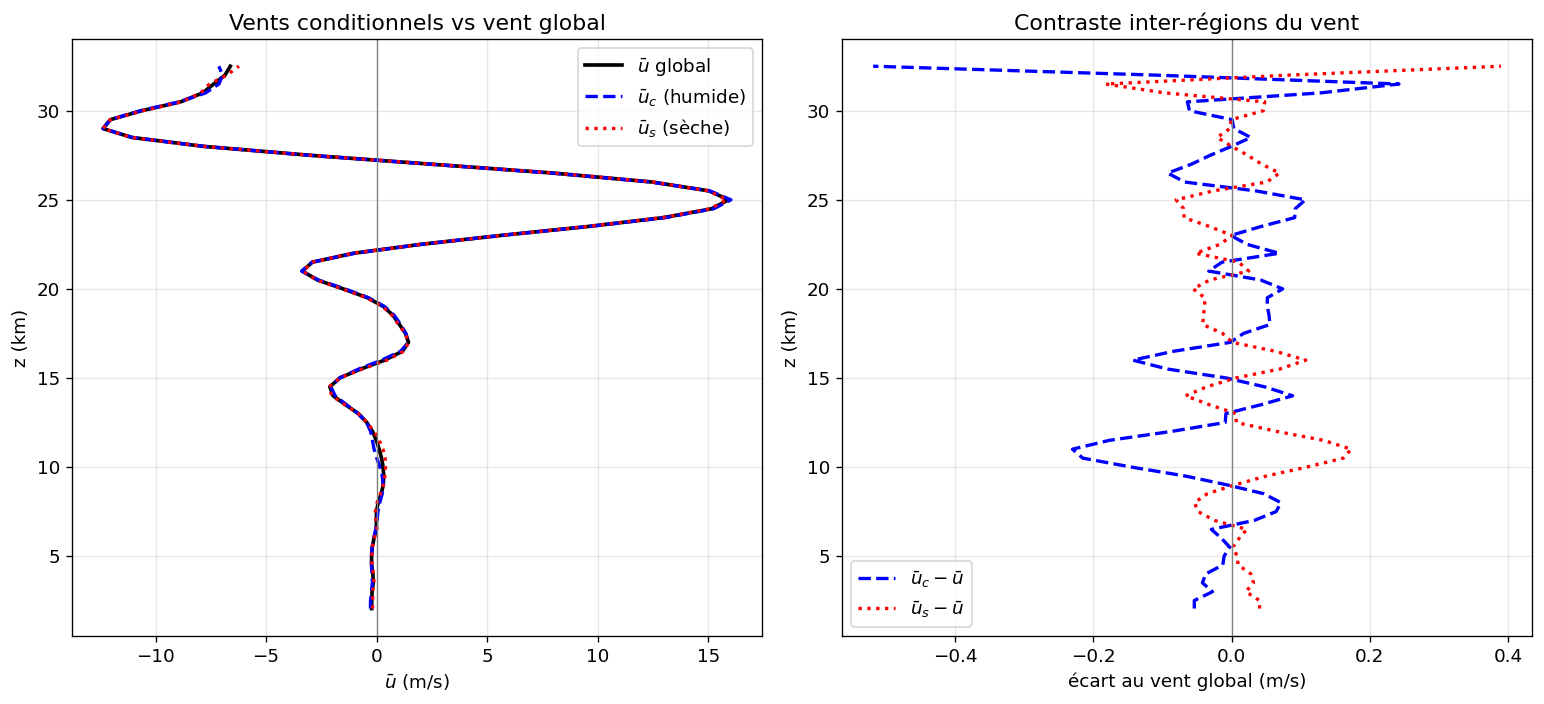

In [4]:
# ============================================================
#  §0bis — DÉCOMPOSITION DU BILAN DE QdM PAR RÉGION (humide Ac / sèche As)
#  Idée (photo) : partir de   rho0 dt<u> + (1/A) ∮ ∇·(rho0 u u) ≈ 0   (z >~ 2 km)
#  et scinder l'intégrale de domaine en deux sous-domaines :
#
#     rho0 dt<u> + (1/A)[ ∫_Ac ∇·(rho0 u u) + ∫_As ∇·(rho0 u u) ] ≈ 0
#
#  Dans CHAQUE région, on décompose le vent par rapport à SA PROPRE moyenne
#  conditionnelle (et non la moyenne globale) :
#       région humide :  u = u_c + u_c'      (u_c = <u>_humide)
#       région sèche  :  u = u_s + u_s'      (u_s = <u>_seche)
#
#  Objectif : (1) plotter u_c, u_s vs u_global pour voir s'ils ressemblent
#             à <u> ou pas  -> mesure du CONTRASTE INTER-RÉGIONS ;
#             (2) isoler, dans le flux vertical de QdM, la part "grande échelle"
#             (contraste des moyennes conditionnelles) de la part "turbulence
#             interne" à chaque région.
#  Tout est calculé niveau par niveau (RAM), fenêtre stationnaire idx_stat.
# ============================================================
import numpy as np, matplotlib.pyplot as plt, gc, xarray as xr

fh = mh.mean()          # fraction d'aire humide
fs = ms.mean()          # fraction d'aire sèche
zkm = alt/1000.0
band2 = alt >= 2000.0   # domaine de validité du bilan (photo : z >~ 2 km)

# --- profils conditionnels : u_c(z), u_s(z), et flux décomposé -----------
u_glob  = np.zeros(n_z)                       # <u> global (rappel)
u_c     = np.zeros(n_z)                       # <u>_humide
u_s     = np.zeros(n_z)                       # <u>_seche
w_c     = np.zeros(n_z); w_s = np.zeros(n_z)  # <w> conditionnels

flux_glob = np.zeros(n_z)                     # rho0 <u'w'>          (réf)
flux_org  = np.zeros(n_z)                     # part CONTRASTE inter-régions (grande échelle)
flux_int  = np.zeros(n_z)                     # part TURBULENCE interne (humide+sèche)
flux_ch   = np.zeros(n_z); flux_cs = np.zeros(n_z)  # interne humide / interne sèche

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values   # (n_stat, ny, nx)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values

    # moyennes globales (sur tout le domaine + temps)
    ub = u.mean(); wb = w.mean()
    u_glob[iz] = ub

    # moyennes CONDITIONNELLES (masques 2D appliqués sur chaque snapshot)
    uc = u[:, mh].mean(); wc = w[:, mh].mean()   # humide
    us = u[:, ms].mean(); ws = w[:, ms].mean()   # sèche
    u_c[iz], w_c[iz] = uc, wc
    u_s[iz], w_s[iz] = us, ws

    # --- flux global (réf) : anomalies vs moyenne GLOBALE ---
    up = u - ub; wp = w - wb
    flux_glob[iz] = rho0[iz] * (up*wp).mean()

    # --- décomposition "loi de la variance totale" ---
    # flux_glob = [ fh*(uc-ub)(wc-wb) + fs*(us-ub)(ws-wb) ]        <- CONTRASTE (org)
    #           + [ fh*<u'w'>_hum      + fs*<u'w'>_sec     ]        <- INTERNE
    org = fh*(uc-ub)*(wc-wb) + fs*(us-ub)*(ws-wb)
    uph = u[:, mh] - uc; wph = w[:, mh] - wc     # fluct. internes humides
    ups = u[:, ms] - us; wps = w[:, ms] - ws     # fluct. internes sèches
    ch  = (uph*wph).mean();  cs = (ups*wps).mean()
    flux_ch[iz] = rho0[iz]*fh*ch
    flux_cs[iz] = rho0[iz]*fs*cs
    flux_org[iz] = rho0[iz]*org
    flux_int[iz] = flux_ch[iz] + flux_cs[iz]

    del u, w, up, wp, uph, wph, ups, wps; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# --- contrôle d'identité : org + int == flux global ? -------------------
resid = np.abs((flux_org+flux_int) - flux_glob).max()
print(f"fraction humide fh={fh:.2f} / sèche fs={fs:.2f}")
print(f"contrôle identité |(org+int) - global|_max = {resid:.2e}  (doit être ~0)")

# part relative du contraste inter-régions dans le flux (médiane 2-18 km)
b = band2 & (alt<=18000)
share_org = np.nanmedian(np.abs(flux_org[b])/(np.abs(flux_glob[b])+1e-30))*100

# ============================================================
#  FIGURE 1 : u_c, u_s ressemblent-ils à <u> ?  (la question de la photo)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.plot(u_glob[band2], zkm[band2], 'k-',  lw=2.2, label=r'$\bar u$ global')
ax.plot(u_c[band2],    zkm[band2], 'b--', lw=2,   label=r'$\bar u_c$ (humide)')
ax.plot(u_s[band2],    zkm[band2], 'r:',  lw=2,   label=r'$\bar u_s$ (sèche)')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'$\bar u$ (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Vents conditionnels vs vent global')
ax.legend(); ax.grid(alpha=.3)

# écart des vents conditionnels au vent global (le "contraste")
ax = axes[1]
ax.plot((u_c-u_glob)[band2], zkm[band2], 'b--', lw=2, label=r'$\bar u_c-\bar u$')
ax.plot((u_s-u_glob)[band2], zkm[band2], 'r:',  lw=2, label=r'$\bar u_s-\bar u$')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'écart au vent global (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Contraste inter-régions du vent')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### §0bis — Lecture du résultat

Le contrôle d'identité se ferme au zéro machine ($\sim2\times10^{-8}$), et la mesure clé est nette :
**le contraste inter-régions ne porte qu'environ 1 % du flux** ; les vents conditionnels $\bar u_c$ et $\bar u_s$ sont quasi superposés au $\bar u$ global (écarts $<0.5$ m/s). 

**C'est un vrai résultat, pas un échec** : dans `large300`, la friction n'est **pas** communiquée par une circulation de grande échelle entre colonnes humides et sèches (le contraste de vent moyen entre régions est négligeable). La quasi-totalité du transport est **interne** — porté par la turbulence convective *à l'intérieur* de chaque région. Cela justifie de se concentrer sur la structure verticale du transport turbulent (§1–§4), et non sur une paramétrisation du contraste humide/sec.

In [5]:
# ============================================================
#  §0bis (v3.1) — BILAN DE QdM PAR SOUS-DOMAINE, TERME PAR TERME
#
#    rho0 dt<u> + (1/A)[ int_Ac div(rho0 u u) + int_As div(rho0 u u) ] = RES
#
#  Sur un SOUS-domaine, div n'est pas reductible a d/dz :
#     (1/A) int_AR div(rho0 u u) = LAT_R + VERT_R
#     LAT_R  = (1/A) int_AR [ dx(rho0 u u) + dy(rho0 v u) ]   (echange lateral)
#     VERT_R = d/dz [ (1/A) int_AR rho0 w u ]                 (flux vertical)
#  Controle : LAT_c + LAT_s = 0 (periodicite du domaine complet).
#  RES = ce que les champs resolus ne ferment pas = -dz(flux sous-maille).
#
#  v3.1 : - appariement temporel 2D/3D (prw plus frequent que les sorties 3D)
#         - reparation des pas de temps ou une region est VIDE (source des NaN)
#         - sommes en float64 (les controles d'identite l'exigent)
# ============================================================
import numpy as np, xarray as xr, gc

# --- pas de grille horizontaux ----------------------------------------
_ds = xr.open_dataset(path3d('ua'))
_yv = _ds[dim_y].values.astype(float)
dy = float(np.mean(np.diff(_yv))) if _yv.size > 1 else dx
if abs(dy) <= 1.5: dy = dx           # coord. en km ou en indice -> on retombe sur dx
_ds.close(); del _ds, _yv; gc.collect()
print(f"dx={dx:.0f} m   dy={dy:.0f} m")

# --- masque humide dynamique, aligne sur les instants 3D ---------------
MASK_MODE = 'fixed_thresh'   # 'static' | 'fixed_thresh' | 'median_t'
PRW_Q     = 0.50             # quantile du seuil fixe (0.50 = mediane)
F_MIN     = 0.02             # fraction d'aire minimale toleree par region

ds_prw = xr.open_dataset(path2d('prw'))
da_prw = ds_prw['prw']
tdim2 = next((d for d in da_prw.dims if da_prw.sizes[d] not in (n_y, n_x)), da_prw.dims[0])
n_t2  = da_prw.sizes[tdim2]

idx3 = np.arange(n_t)[idx_stat]
if n_t2 == n_t:
    idx2 = idx3
else:
    _d = xr.open_dataset(path3d('ua'))
    t3 = _d[dim_t].values if dim_t in _d.coords else None
    _d.close()
    t2 = da_prw[tdim2].values if tdim2 in da_prw.coords else None
    def _num(a):
        return (a.astype('datetime64[s]').astype(np.float64)
                if np.issubdtype(a.dtype, np.datetime64) else a.astype(np.float64))
    if t3 is not None and t2 is not None and t3.size == n_t and t2.size == n_t2:
        a3, a2 = _num(t3), _num(t2)
        idx2 = np.abs(a2[None, :] - a3[:, None]).argmin(1)[idx_stat]
        print(f"appariement par coordonnee : ecart max {np.abs(a2[idx2]-a3[idx3]).max():.0f}")
    else:
        assert n_t2 % n_t == 0, f"pas de correspondance simple : {n_t2} pas 2D / {n_t} pas 3D"
        r = n_t2 // n_t
        idx2 = ((np.arange(n_t) + 1)*r - 1)[idx_stat]
        print(f"appariement par pas constant : 1 snapshot 2D sur {r}")

prw = da_prw.isel({tdim2: idx2}).values.astype(np.float32)   # (n_stat, ny, nx)
ds_prw.close(); del da_prw
assert prw.shape[0] == n_stat, f"{prw.shape[0]} != n_stat={n_stat}"

if MASK_MODE == 'static':
    maskc = np.broadcast_to(mh, (n_stat,) + mh.shape).copy()
elif MASK_MODE == 'median_t':
    maskc = prw > np.median(prw.reshape(n_stat, -1), axis=1).astype(np.float32)[:, None, None]
else:
    seuil = np.float32(np.quantile(prw, PRW_Q))
    maskc = prw > seuil
    print(f"seuil PRW fixe (q={PRW_Q:.2f}) = {float(seuil):.2f} kg/m2")

# --- REPARATION des pas de temps degeneres (une region vide => NaN) ----
frac = maskc.reshape(n_stat, -1).mean(1)
bad  = np.where((frac < F_MIN) | (frac > 1.0 - F_MIN))[0]
if bad.size:
    print(f"/!\\ {bad.size} pas de temps degeneres (fraction humide hors [{F_MIN},{1-F_MIN}])")
    print(f"    -> seuil recalcule localement a la mediane de l'instant : t={bad[:10]}...")
    for t in bad:
        maskc[t] = prw[t] > np.float32(np.median(prw[t]))
    frac = maskc.reshape(n_stat, -1).mean(1)
del prw; gc.collect()

Mc     = maskc.reshape(n_stat, -1)
Ncell  = Mc.shape[1]
Nc     = Mc.sum(1).astype(np.float64); Ns = Ncell - Nc
assert Nc.min() > 0 and Ns.min() > 0, "region encore vide apres reparation"
fc_t   = Nc/Ncell; fs_t = Ns/Ncell
churn  = float((maskc[1:] != maskc[:-1]).mean())
del maskc; gc.collect()
print(f"fraction humide : moy {fc_t.mean():.3f}  min {fc_t.min():.3f}  max {fc_t.max():.3f}")
print(f"renouvellement du masque entre 2 pas : {churn*100:.1f} % des mailles changent de region")

# --- helpers (sommes en float64 : les controles d'identite en dependent)
def _means(X):
    """moyennes : globale, conditionnelle humide, conditionnelle seche"""
    tot = X.sum(1, dtype=np.float64); sc = (X*Mc).sum(1, dtype=np.float64)
    return tot/Ncell, sc/Nc, (tot-sc)/Ns

def _parts(X):
    """integrales partielles normalisees par A : (1/A)int_Ac , (1/A)int_As"""
    tot = X.sum(1, dtype=np.float64); sc = (X*Mc).sum(1, dtype=np.float64)
    return sc/Ncell, (tot-sc)/Ncell

Z = lambda: np.zeros((n_z, n_stat))
Ug, Uc, Us = Z(), Z(), Z()           # <u>, <u>_c, <u>_s
Wg, Wc, Ws = Z(), Z(), Z()
UWg, UWc, UWs = Z(), Z(), Z()        # <uw> totaux (pas des anomalies)
UUc, UUs, WWc, WWs = Z(), Z(), Z(), Z()
TENc, TENs = Z(), Z()                # (1/A) int_AR rho0 dt u
LATc, LATs = Z(), Z()                # flux lateral a travers l'interface

# --- boucle niveau par niveau -----------------------------------------
ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    v = ds_v['va'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    r = np.float32(rho0[iz])

    # ---- LAT : divergence horizontale, differences centrees periodiques
    F = u*u
    divh = (np.roll(F,-1,axis=2) - np.roll(F,1,axis=2))/np.float32(2*dx)
    F = v*u; del v
    divh += (np.roll(F,-1,axis=1) - np.roll(F,1,axis=1))/np.float32(2*dy)
    del F; gc.collect()
    pc, ps = _parts(divh.reshape(n_stat,-1)); LATc[iz] = r*pc; LATs[iz] = r*ps
    del divh; gc.collect()

    # ---- TEND : derivee temporelle ponctuelle, PUIS moyenne masquee
    dudt = np.gradient(u, dt_phys, axis=0)
    pc, ps = _parts(dudt.reshape(n_stat,-1)); TENc[iz] = r*pc; TENs[iz] = r*ps
    del dudt; gc.collect()

    # ---- moments conditionnels
    U = u.reshape(n_stat,-1); W = w.reshape(n_stat,-1); del u, w
    Ug[iz], Uc[iz], Us[iz] = _means(U)
    Wg[iz], Wc[iz], Ws[iz] = _means(W)
    UWg[iz], UWc[iz], UWs[iz] = _means(U*W)
    _, UUc[iz], UUs[iz] = _means(U*U)
    _, WWc[iz], WWs[iz] = _means(W*W)
    del U, W; gc.collect()

ds_u.close(); ds_v.close(); ds_w.close(); gc.collect()

_nan = {k: int(np.isnan(v).sum()) for k, v in
        dict(Uc=Uc, Us=Us, Wc=Wc, Ws=Ws, UWc=UWc, UWs=UWs, LATc=LATc, TENc=TENc).items()}
print("NaN residuels :", _nan if any(_nan.values()) else "aucun")
print("termes bruts calcules.")


dx=1000 m   dy=1000 m
appariement par pas constant : 1 snapshot 2D sur 24
seuil PRW fixe (q=0.50) = 30.26 kg/m2
/!\ 5 pas de temps degeneres (fraction humide hors [0.02,0.98])
    -> seuil recalcule localement a la mediane de l'instant : t=[0 1 2 3 4]...
fraction humide : moy 0.475  min 0.325  max 0.979
renouvellement du masque entre 2 pas : 7.4 % des mailles changent de region
NaN residuels : aucun
termes bruts calcules.


In [6]:
 #============================================================
#  §0bis.B — assemblage des termes, controles exacts, fermeture
# ============================================================
R = rho0[:, None]

# --- flux verticaux resolus, par region --------------------------------
MFc  = R*fc_t*Uc*Wc                        # circulation organisee humide
MFs  = R*fs_t*Us*Ws                        #                       seche
INTc = R*fc_t*(UWc - Uc*Wc)                # turbulence interne humide
INTs = R*fs_t*(UWs - Us*Ws)                #                    seche
PHI  = R*UWg                               # flux vertical total resolu

VERTc = np.gradient(MFc + INTc, alt, axis=0)
VERTs = np.gradient(MFs + INTs, alt, axis=0)

# --- bilan complet -----------------------------------------------------
BUDc = TENc + LATc + VERTc
BUDs = TENs + LATs + VERTs
RES  = BUDc + BUDs                          # = -dz(flux sous-maille)



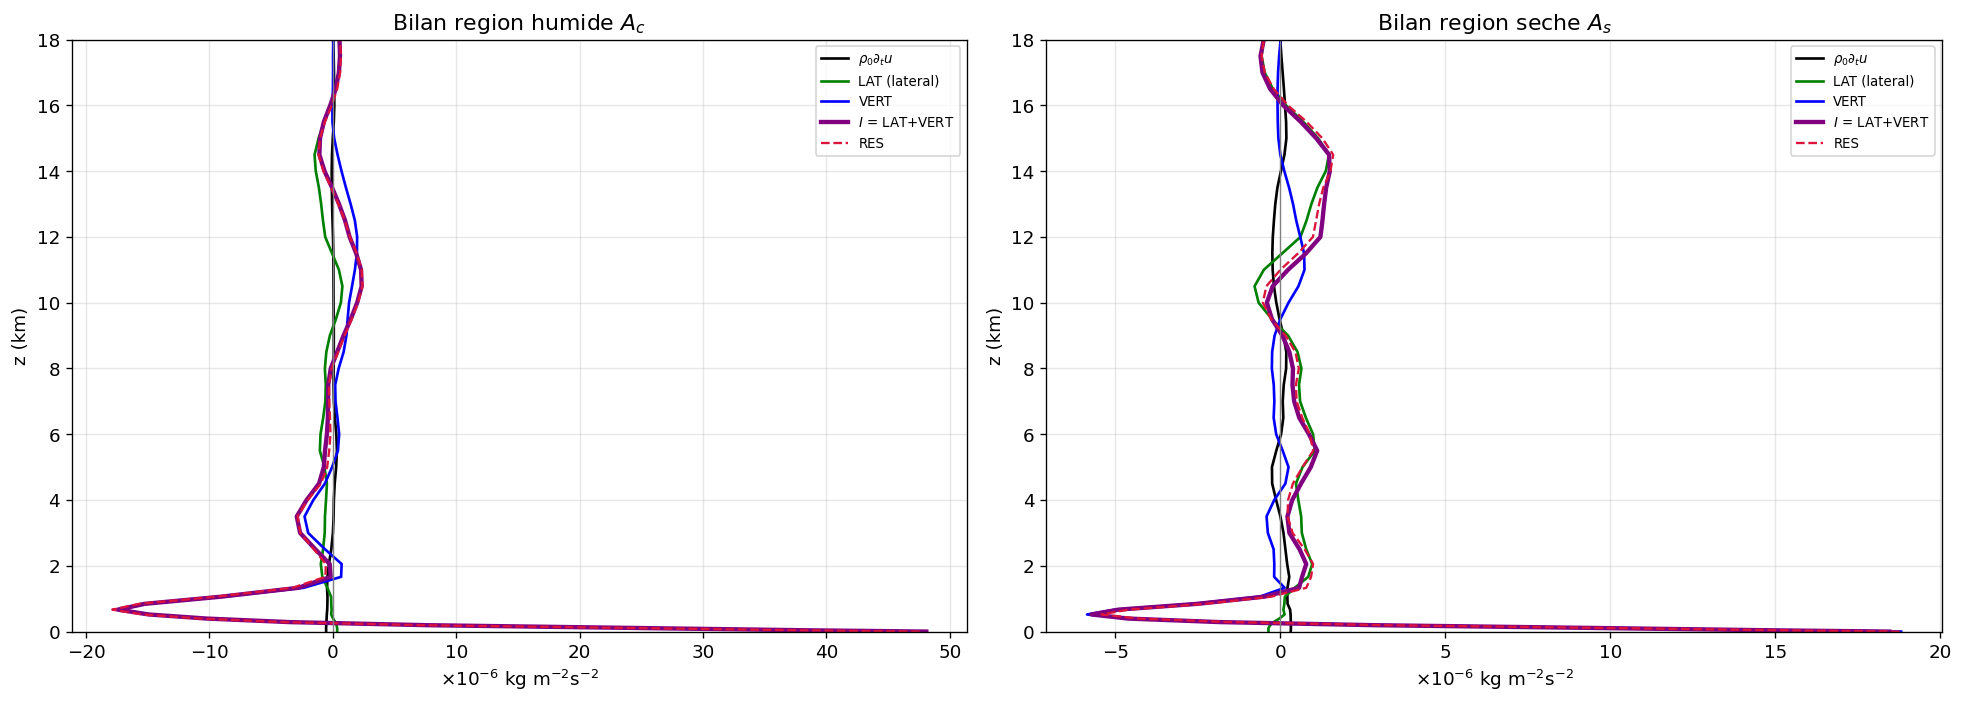

In [7]:
# ============================================================
#  §0bis.D — LES DEUX INTEGRALES, EXPLICITEMENT
#
#     I_c = (1/A) int_Ac div(rho0 u u) dA = LAT_c + VERT_c
#     I_s = (1/A) int_As div(rho0 u u) dA = LAT_s + VERT_s
#
#  Bilan par region :  TEN_R + I_R = RES_R      (RES_R = -sous-maille region R)
#  Bilan global     : (TEN_c+TEN_s) + (I_c+I_s) = RES
#
#  Le masque vient du PRW (colonne) => il ne depend PAS de z, donc
#  d/dz commute avec int_A_R : VERT_R = d/dz[(1/A) int_A_R rho0 w u].
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

SMOOTH = 3          # lissage vertical POUR L'AFFICHAGE seulement (0 = brut)

DIVc = LATc + VERTc                 # <- integrale 1
DIVs = LATs + VERTs                 # <- integrale 2
RESc = TENc + DIVc                  # residu sous-maille, region humide
RESs = TENs + DIVs                  #                     region seche

# --- figures -----------------------------------------------------------
sm = (lambda a: uniform_filter1d(a, SMOOTH)) if SMOOTH else (lambda a: a)
m  = alt <= 18000
zk = zkm

fig, ax = plt.subplots(1, 2, figsize=(16.5, 6))

for k, (lab, TE, LA, VE, DI, RE) in enumerate([
        ('humide $A_c$', TENc, LATc, VERTc, DIVc, RESc),
        ('seche $A_s$',  TENs, LATs, VERTs, DIVs, RESs)]):
    a = ax[k]
    a.plot(sm(TE.mean(1))[m]*1e6, zk[m], 'k',  lw=1.6, label=r'$\rho_0\partial_t u$')
    a.plot(sm(LA.mean(1))[m]*1e6, zk[m], 'g',  lw=1.6, label='LAT (lateral)')
    a.plot(sm(VE.mean(1))[m]*1e6, zk[m], 'b',  lw=1.6, label='VERT')
    a.plot(sm(DI.mean(1))[m]*1e6, zk[m], 'purple', lw=2.6, label=r'$I$ = LAT+VERT')
    a.plot(sm(RE.mean(1))[m]*1e6, zk[m], 'crimson', lw=1.4, ls='--', label='RES')
    a.axvline(0, color='grey', lw=.8)
    a.set_title(f'Bilan region {lab}'); a.set_xlabel(r'$\times10^{-6}$ kg m$^{-2}$s$^{-2}$')
    a.set_ylabel('z (km)'); a.legend(fontsize=8)

for a in ax: a.grid(alpha=.3); a.set_ylim(0, 18)
plt.tight_layout(); plt.show()

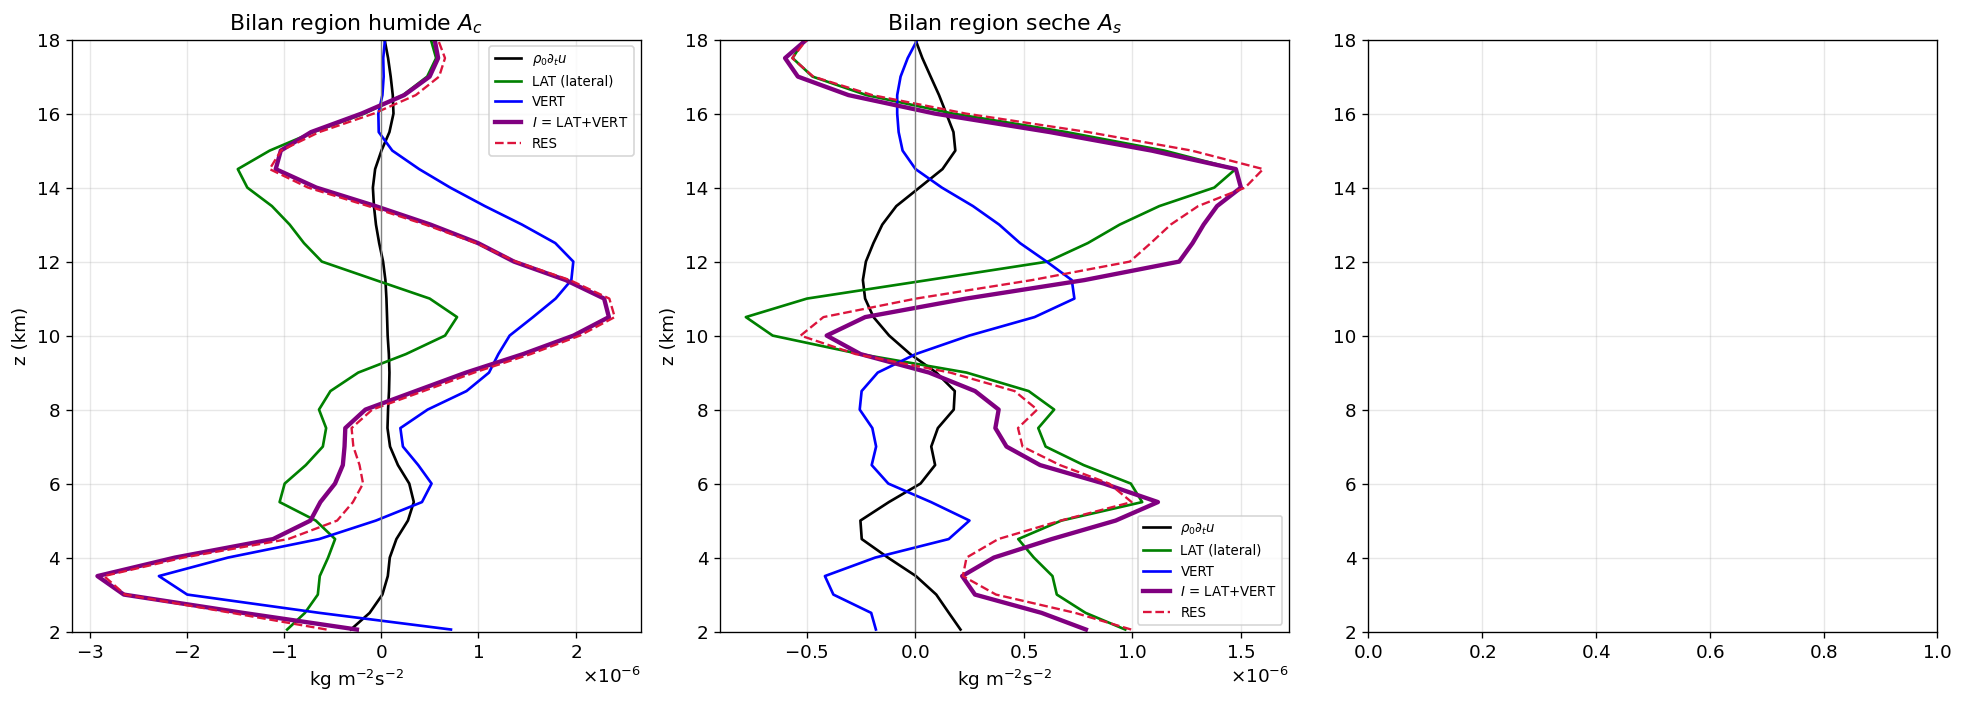

In [8]:
# --- figures (2-18 km) -------------------------------------------------
bnd = (alt >= 2000) & (alt <= 18000)
sm = (lambda a: uniform_filter1d(a, SMOOTH)) if SMOOTH else (lambda a: a)
m  = bnd                      # <- fenetre 2-18 km, coherente avec le tableau
zk = zkm

fig, ax = plt.subplots(1, 3, figsize=(16.5, 6))

for k, (lab, TE, LA, VE, DI, RE) in enumerate([
        ('humide $A_c$', TENc, LATc, VERTc, DIVc, RESc),
        ('seche $A_s$',  TENs, LATs, VERTs, DIVs, RESs)]):
    a = ax[k]
    a.plot(sm(TE.mean(1))[m], zk[m], 'k',  lw=1.6, label=r'$\rho_0\partial_t u$')
    a.plot(sm(LA.mean(1))[m], zk[m], 'g',  lw=1.6, label='LAT (lateral)')
    a.plot(sm(VE.mean(1))[m], zk[m], 'b',  lw=1.6, label='VERT')
    a.plot(sm(DI.mean(1))[m], zk[m], 'purple', lw=2.6, label=r'$I$ = LAT+VERT')
    a.plot(sm(RE.mean(1))[m], zk[m], 'crimson', lw=1.4, ls='--', label='RES')
    a.axvline(0, color='grey', lw=.8)
    a.set_title(f'Bilan region {lab}'); a.set_xlabel(r'kg m$^{-2}$s$^{-2}$')
    a.set_ylabel('z (km)'); a.legend(fontsize=8)


for a in ax:
    a.grid(alpha=.3); a.set_ylim(2, 18)
    a.ticklabel_format(axis='x', style='sci', scilimits=(-2, 2), useMathText=True)
plt.tight_layout(); plt.show()



Résultat central : $\mathrm{LAT}$ est du même ordre que $\mathrm{VERT}$. Dans
chaque région, l'échange latéral et la convergence verticale sont comparables en
amplitude et souvent de signes opposés, entre 10 et 14 km dans l'humide, ils se
compensent partiellement, et c'est leur somme qui constitue $I_c$.
$I_c$ et $I_s$ sonten opposition de phase.

Il existe donc une redistribution horizontale de quantité de mouvement entre
colonnes humides et sèches, structurellement invisible dans un bilan de
domaine : elle s'annule exactement à la sommation
($\mathrm{LAT}_c=-\mathrm{LAT}_s$). 


[ctrl] ORG + INT = rho0<u'w'>       : erreur relative 2.76e-16


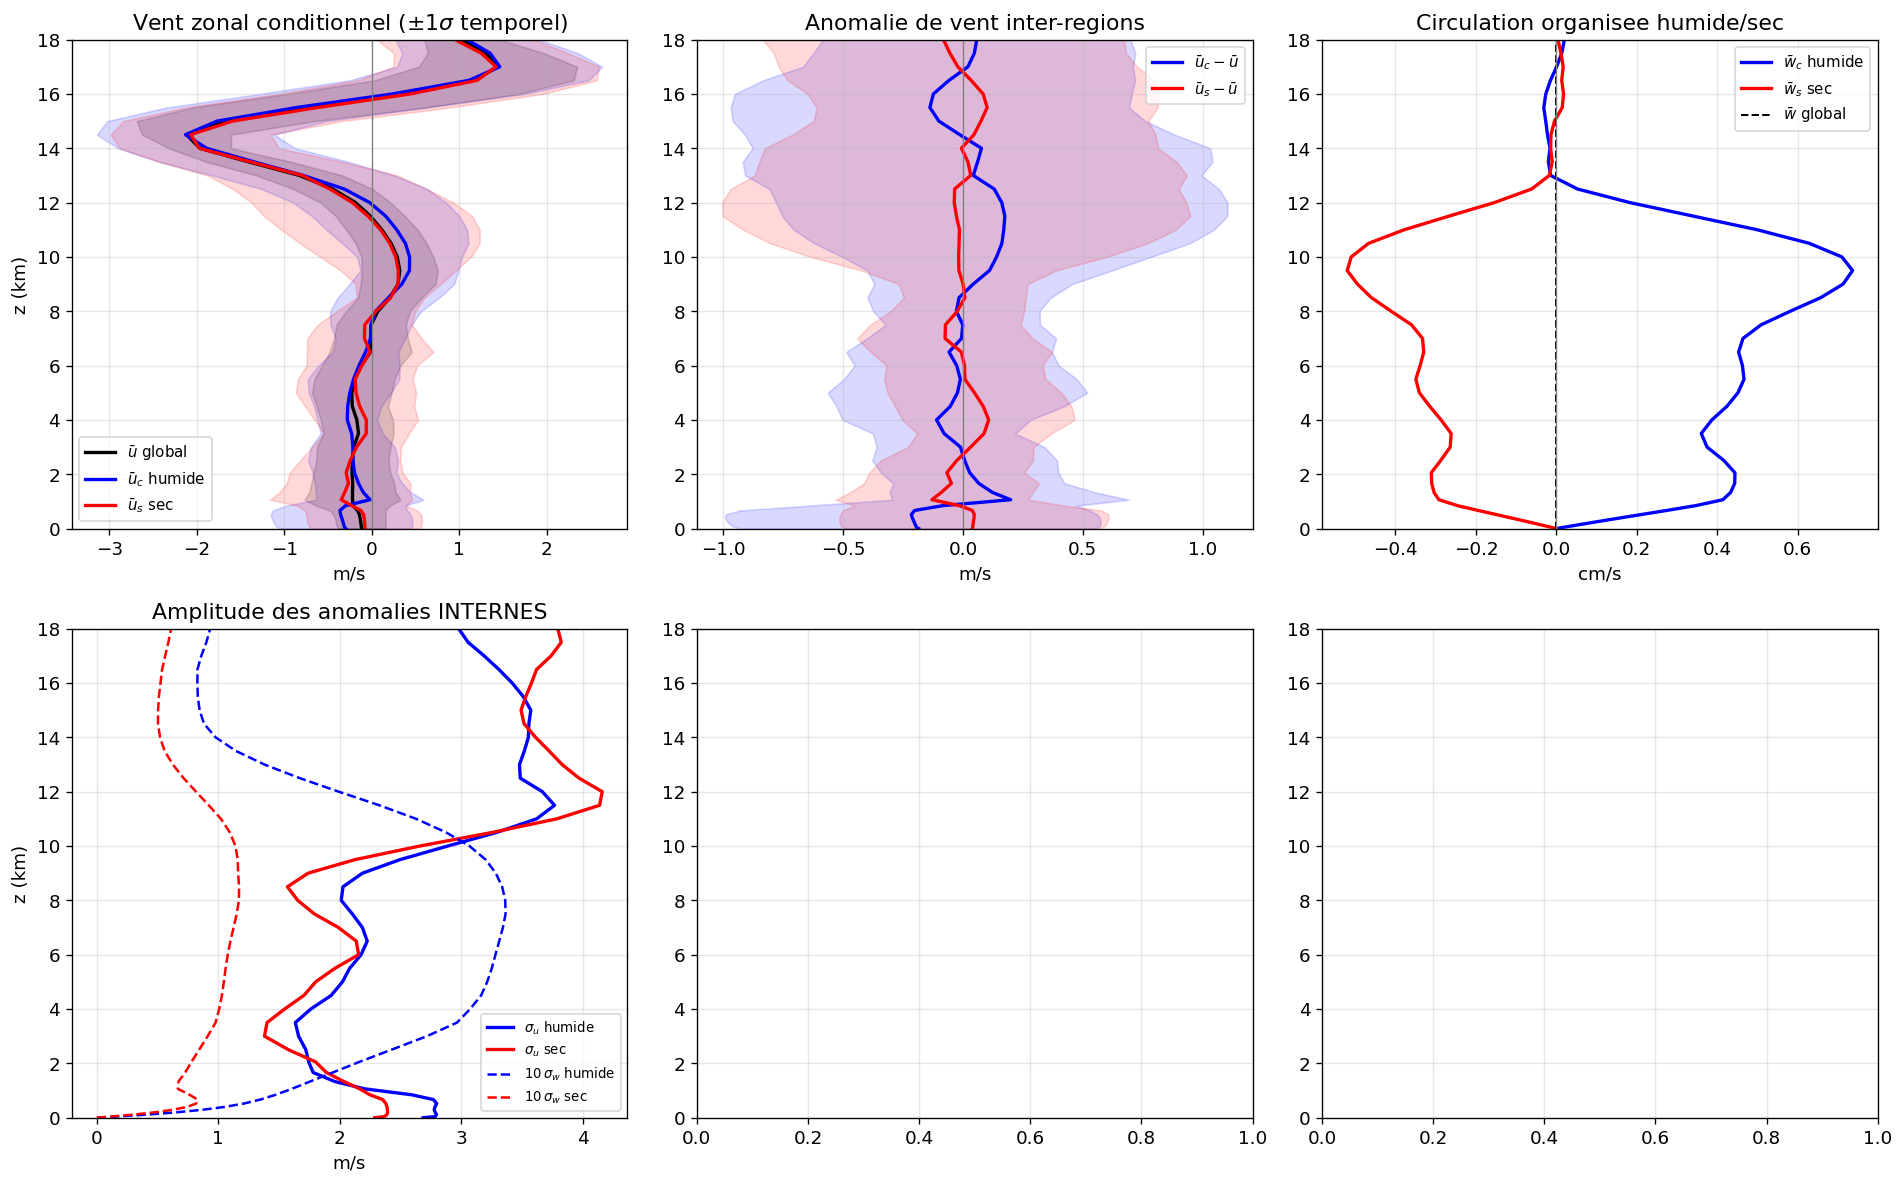

In [9]:
# ============================================================
#  §0bis.C — vents conditionnels, anomalies, amplitudes internes
# ============================================================
import matplotlib.pyplot as plt

su_c = np.sqrt(np.maximum(UUc - Uc**2, 0)); sw_c = np.sqrt(np.maximum(WWc - Wc**2, 0))
su_s = np.sqrt(np.maximum(UUs - Us**2, 0)); sw_s = np.sqrt(np.maximum(WWs - Ws**2, 0))
zk = zkm; m = alt <= 18000

def mt(A): return A.mean(1)
def st(A): return A.std(1)

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

a = ax[0,0]
for A, c, l in [(Ug,'k',r'$\bar u$ global'), (Uc,'b',r'$\bar u_c$ humide'), (Us,'r',r'$\bar u_s$ sec')]:
    a.plot(mt(A)[m], zk[m], color=c, lw=2, label=l)
    a.fill_betweenx(zk[m], (mt(A)-st(A))[m], (mt(A)+st(A))[m], color=c, alpha=.15)
a.axvline(0, color='grey', lw=.8); a.set_xlabel('m/s'); a.set_ylabel('z (km)')
a.set_title(r'Vent zonal conditionnel ($\pm1\sigma$ temporel)'); a.legend(fontsize=9)


# --- decomposition du flux : contraste vs interne, PAR PAS DE TEMPS ----
dUc, dWc = Uc - Ug, Wc - Wg
dUs, dWs = Us - Ug, Ws - Wg
ORG  = R*(fc_t*dUc*dWc + fs_t*dUs*dWs)      # contraste inter-regions
INT  = INTc + INTs                          # turbulence interne
FLXp = R*(UWg - Ug*Wg)                      # rho0 <u'w'> global
print(f"[ctrl] ORG + INT = rho0<u'w'>       : erreur relative "
      f"{np.abs(ORG+INT-FLXp).max()/(np.abs(FLXp).max()+1e-30):.2e}")



a = ax[0,1]
a.plot(mt(dUc)[m], zk[m], 'b', lw=2, label=r'$\bar u_c-\bar u$')
a.plot(mt(dUs)[m], zk[m], 'r', lw=2, label=r'$\bar u_s-\bar u$')
a.fill_betweenx(zk[m], (mt(dUc)-st(dUc))[m], (mt(dUc)+st(dUc))[m], color='b', alpha=.15)
a.fill_betweenx(zk[m], (mt(dUs)-st(dUs))[m], (mt(dUs)+st(dUs))[m], color='r', alpha=.15)
a.axvline(0, color='grey', lw=.8); a.set_xlabel('m/s')
a.set_title("Anomalie de vent inter-regions"); a.legend(fontsize=9)

a = ax[0,2]
a.plot(mt(Wc)[m]*100, zk[m], 'b', lw=2, label=r'$\bar w_c$ humide')
a.plot(mt(Ws)[m]*100, zk[m], 'r', lw=2, label=r'$\bar w_s$ sec')
a.plot(mt(Wg)[m]*100, zk[m], 'k--', lw=1.2, label=r'$\bar w$ global')
a.axvline(0, color='grey', lw=.8); a.set_xlabel('cm/s')
a.set_title('Circulation organisee humide/sec'); a.legend(fontsize=9)

a = ax[1,0]
a.plot(mt(su_c)[m], zk[m], 'b', lw=2, label=r"$\sigma_u$ humide")
a.plot(mt(su_s)[m], zk[m], 'r', lw=2, label=r"$\sigma_u$ sec")
a.plot(mt(sw_c)[m]*10, zk[m], 'b--', lw=1.5, label=r"$10\,\sigma_w$ humide")
a.plot(mt(sw_s)[m]*10, zk[m], 'r--', lw=1.5, label=r"$10\,\sigma_w$ sec")
a.set_xlabel('m/s'); a.set_ylabel('z (km)')
a.set_title("Amplitude des anomalies INTERNES"); a.legend(fontsize=8)

for a in ax.ravel(): a.grid(alpha=.3); a.set_ylim(0, 18)
plt.tight_layout(); plt.show()

---
# §1 — Une fermeture grande-échelle reconstruit-elle le flux&nbsp;?


seuil colonne (q=0.90) = 1.08e-02 s-1  |  S : med 7.53e-03  max 1.85e-02
colonnes qualifiees : 9.8 %  (19690 px x-t) en 154 regions connexes >= 6 px
seuil local (q=0.90)  = 5.21e-03 s-1  |  10.0 % des points (x,z,t) de la bande
blocs temporels : train 50 / val 25 / test 25 pas

zone                 modele          NSE_tr   NSE_va   NSE_te  NSE_cst   r_te      cond  rg
toutes               A shear-3       +0.001   +0.001   +0.001   -0.000  +0.03   1.3e+01   3
toutes               B rho0u-3       +0.002   +0.002   +0.001   -0.000  +0.03   2.2e+00   3
toutes               A+B mixte       +0.002   +0.002   +0.001   -0.000  +0.03   2.4e+02   6
toutes               baseline dz     +0.000   +0.000   +0.000   -0.000  +0.01   1.0e+00   1
----------------------------------------------------------------------------------------
colonnes fortes      A shear-3       +0.001   -0.001   -0.000   -0.000  +0.01   1.4e+01   3
colonnes fortes      B rho0u-3       +0.002   +0.001   +0.001   -0.000  +0.03   

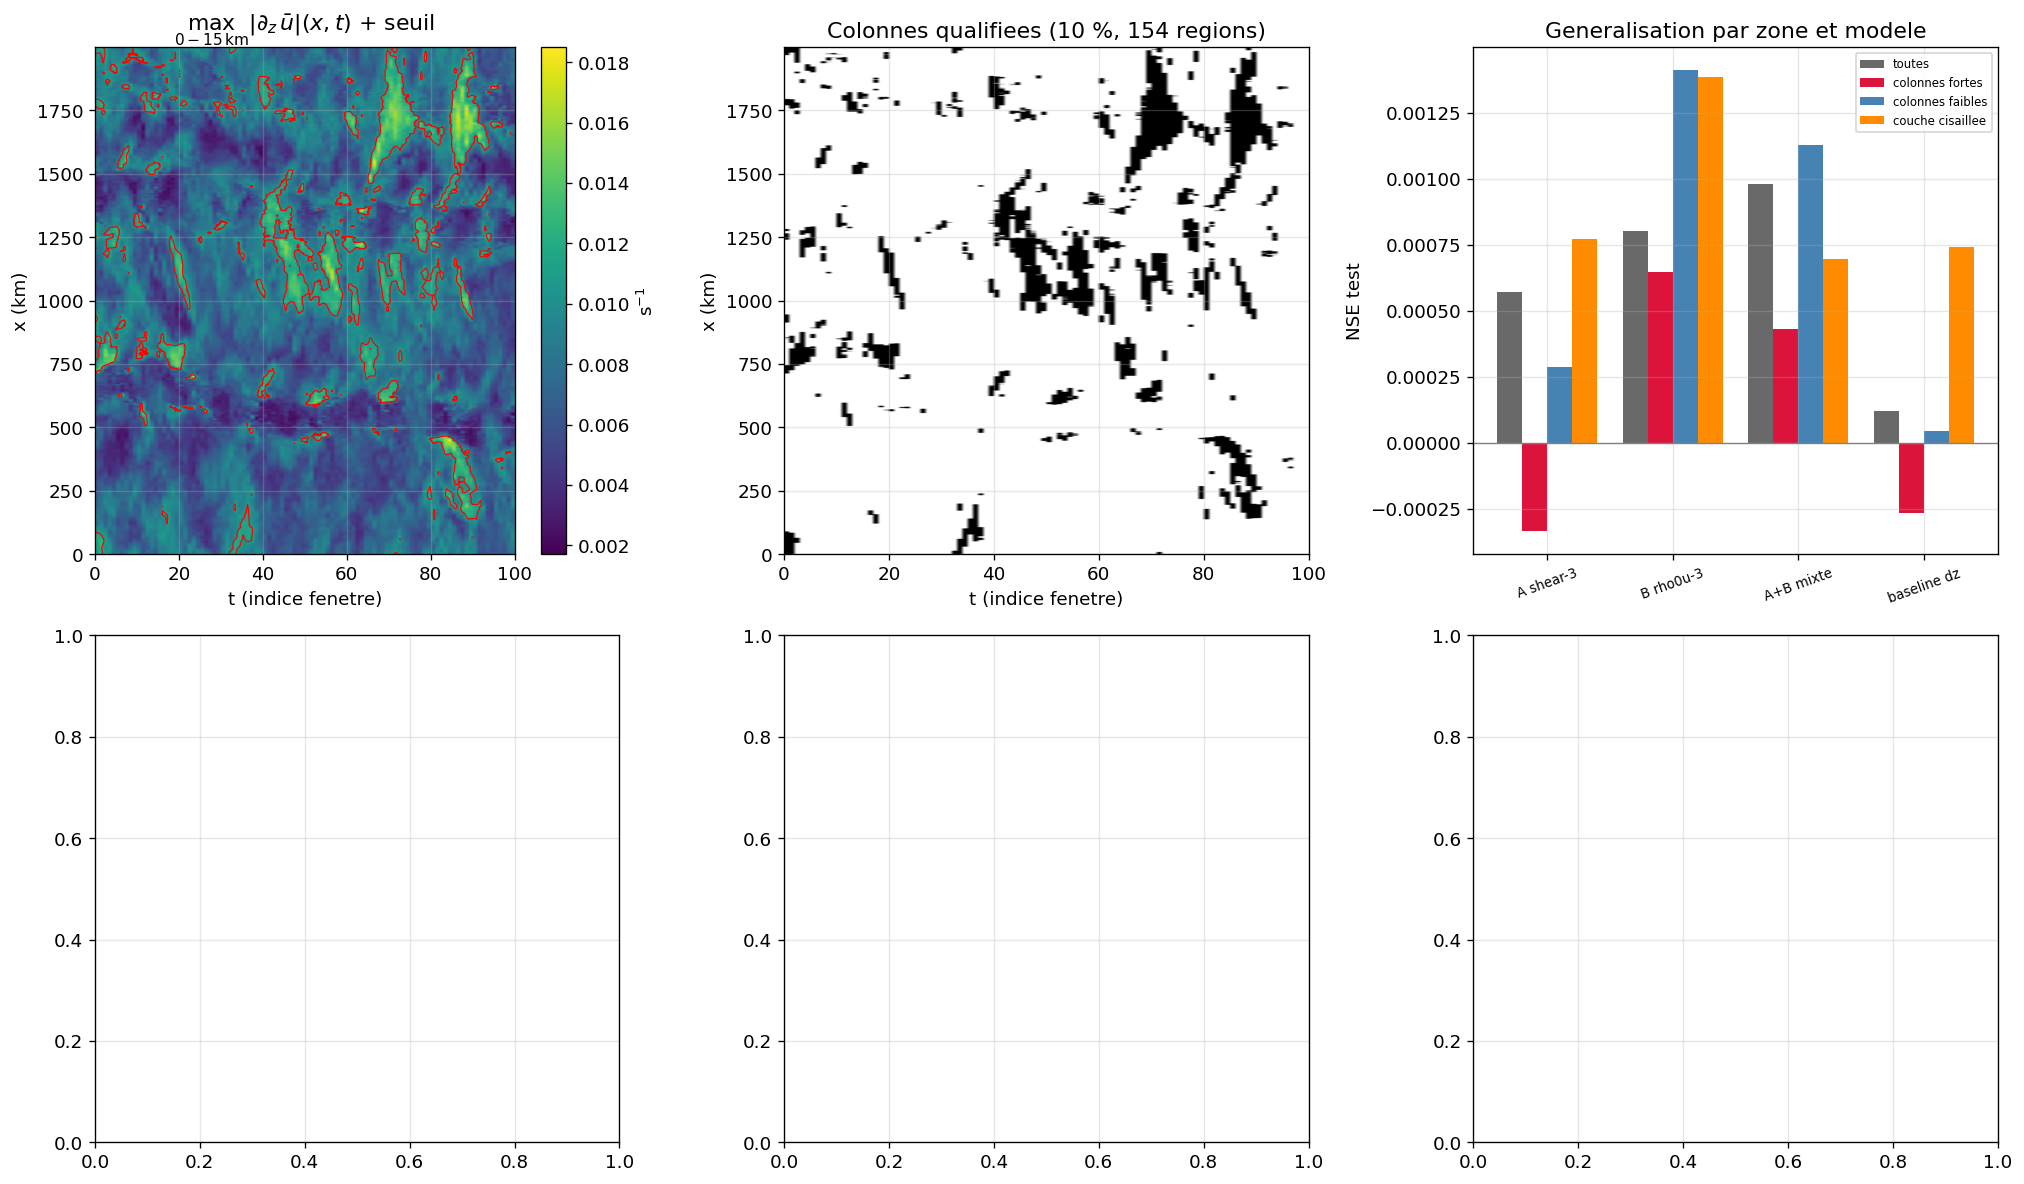

In [13]:
# ============================================================
#  §1 (v4) — FERMETURE LINEAIRE LOCALE TESTEE SUR LES ZONES DE FORT CISAILLEMENT
#
#  v4 corrige deux defauts de la v3 :
#   (1) ridge SANS ordonnee a l'origine + y non centre -> la prediction etait
#       de moyenne nulle par construction (NSE ~ -mean^2/var, sans contenu).
#       Ici : y centre sur le train, intercept non penalise, colonnes
#       constantes ecartees.
#   (2) le critere max_z |dz u| selectionne des colonnes cisaillees, mais la
#       MOYENNE de zone lisse tout (maxima a des z et des signes differents).
#       Ici : l'echantillon de regression est la COLONNE (x,t), pas la moyenne
#       de zone -> le cisaillement de la bibliotheque est celui qu'on a
#       selectionne. Ajout d'un conditionnement local (x,z,t).
#
#  Cible : flux interne a la colonne  rho0 <(u-<u>_y)(w-<w>_y)>_y  (z,t,x)
#  Modeles : (A) c1 dz u + c2 z Hz dz u + c3 z dz u
#            (B) a rho0 u + b dz(rho0 u) + g dzz(rho0 u)
#            (A+B) et baseline 1 terme (dz u seul)
#  Protocole : blocs temporels train/val/test ; alpha sur VAL, score sur TEST.
# ============================================================
import numpy as np, xarray as xr, matplotlib.pyplot as plt, gc
from scipy.ndimage import label, uniform_filter

# ---------------- configuration --------------------------------------
Z_SHEAR_MAX = 15000.0        # fenetre du critere par colonne
Q_SEUIL     = 0.90           # quantile "fort cisaillement" (colonnes)
Q_LOCAL     = 0.90           # quantile "couche cisaillee"  (niveaux)
LISSE_XT    = 0              # lissage de S(x,t) avant seuillage (0 = brut)
MIN_PIX     = 6              # taille min d'une region connexe (px x-t)
Z_LO, Z_HI  = 2000.0, 18000.0
FRAC        = (0.50, 0.25, 0.25)          # train / val / test (blocs temporels)
ALPHAS      = np.logspace(-4, 5, 37)
MAX_SAMP    = 200_000        # plafond d'echantillons par bloc (RAM)
SEED        = 0

zk   = alt/1000.0
band = (alt >= Z_LO) & (alt <= Z_HI); ib = np.where(band)[0]
Hz   = (Z_SHEAR_MAX - alt)/1000 #np.gradient(np.log(rho0), alt)     # d ln(rho0)/dz
rng  = np.random.default_rng(SEED)

# ============================================================
#  ETAPE 1 — profils par colonne + flux interne par colonne
# ============================================================
u_y      = np.zeros((n_z, n_stat, n_x), dtype=np.float32)   # <u>_y (x,t)
flux_col = np.zeros((n_z, n_stat, n_x), dtype=np.float32)   # rho0 <u'w'>_y
flux_dom = np.zeros((n_z, n_stat), dtype=np.float64)        # flux de domaine (ref)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    uy  = u.mean(axis=1); wy = w.mean(axis=1)                # (n_stat, n_x)
    uwy = (u*w).mean(axis=1)
    u_y[iz]      = uy
    flux_col[iz] = rho0[iz]*(uwy - uy*wy)                    # interne a la colonne
    ug = u.mean(axis=(1, 2)); wg = w.mean(axis=(1, 2))
    flux_dom[iz] = rho0[iz]*((u*w).mean(axis=(1, 2)) - ug*wg)
    del u, w, uy, wy, uwy; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

dz_uy = np.gradient(u_y, alt, axis=0).astype(np.float32)

# ============================================================
#  ETAPE 2 — detection des zones de fort cisaillement dans (x,t)
# ============================================================
sel_z = alt <= Z_SHEAR_MAX
S     = np.abs(dz_uy[sel_z]).max(axis=0)                     # (n_stat, n_x)
S_f   = uniform_filter(S, LISSE_XT) if LISSE_XT else S
seuil = float(np.quantile(S_f, Q_SEUIL))
brut  = S_f > seuil

lab, nlab = label(brut)                    # x non periodique : cf. note en fin
if MIN_PIX > 1:
    tail = np.bincount(lab.ravel()); tail[0] = 0
    brut = np.isin(lab, np.where(tail >= MIN_PIX)[0])
    lab, nlab = label(brut)
fort, faible = brut, ~brut

# conditionnement LOCAL (niveau par niveau), dans la bande d'etude
absdz  = np.abs(dz_uy)
s_loc  = float(np.quantile(absdz[band], Q_LOCAL))
couche = absdz > s_loc                                        # (n_z, n_stat, n_x)

print(f"seuil colonne (q={Q_SEUIL:.2f}) = {seuil:.2e} s-1  |  "
      f"S : med {np.median(S):.2e}  max {S.max():.2e}")
print(f"colonnes qualifiees : {fort.mean()*100:.1f} %  ({fort.sum()} px x-t) "
      f"en {nlab} regions connexes >= {MIN_PIX} px")
print(f"seuil local (q={Q_LOCAL:.2f})  = {s_loc:.2e} s-1  |  "
      f"{couche[band].mean()*100:.1f} % des points (x,z,t) de la bande")

# ============================================================
#  ETAPE 3 — bibliotheque vectorisee (n_z, n_stat, n_x)
# ============================================================
A3 = alt[:, None, None]; H3 = Hz[:, None, None]; R3 = rho0[:, None, None]

def term(name):
    if name == 'dudz'      : return dz_uy
    if name == 'zHz_dudz'  : return (A3*H3*dz_uy).astype(np.float32)
    if name == 'z_dudz'    : return (A3*dz_uy).astype(np.float32)
    ru = (R3*u_y).astype(np.float32)
    if name == 'rho0_u'    : return ru
    if name == 'dz_rho0_u' : return np.gradient(ru, alt, axis=0).astype(np.float32)
    if name == 'dzz_rho0_u': return np.gradient(np.gradient(ru, alt, axis=0),
                                                alt, axis=0).astype(np.float32)
    raise KeyError(name)

MODELES = {'A shear-3'  : ['dudz', 'zHz_dudz', 'z_dudz'],
           'B rho0u-3'  : ['rho0_u', 'dz_rho0_u', 'dzz_rho0_u'],
           'A+B mixte'  : ['dudz', 'zHz_dudz', 'z_dudz',
                           'rho0_u', 'dz_rho0_u', 'dzz_rho0_u'],
           'baseline dz': ['dudz']}

# ---- zones : masques 3D (n_z, n_stat, n_x) restreints a la bande -----
B3 = band[:, None, None]
ZONES = {'toutes'            : np.broadcast_to(B3, dz_uy.shape),
         'colonnes fortes'   : B3 & fort[None, :, :],
         'colonnes faibles'  : B3 & faible[None, :, :],
         'couche cisaillee'  : B3 & couche}

# ---- decoupage temporel en 3 blocs -----------------------------------
i1 = int(FRAC[0]*n_stat); i2 = int((FRAC[0]+FRAC[1])*n_stat)
TBLOCS = {'tr': np.arange(0, i1), 'va': np.arange(i1, i2), 'te': np.arange(i2, n_stat)}
print(f"blocs temporels : train {i1} / val {i2-i1} / test {n_stat-i2} pas")

def echantillons(zone, ts):
    """indices lineaires d'un sous-ensemble d'echantillons (z,t,x)"""
    m = zone.copy()
    keep_t = np.zeros(n_stat, bool); keep_t[ts] = True
    m &= keep_t[None, :, None]
    idx = np.flatnonzero(m.ravel())
    if idx.size > MAX_SAMP:
        idx = rng.choice(idx, MAX_SAMP, replace=False)
    return idx

def design(names, idx):
    return np.column_stack([term(nm).ravel()[idx].astype(np.float64) for nm in names])

# ============================================================
#  ETAPE 4 — ridge AVEC ordonnee a l'origine, alpha choisi sur VAL
# ============================================================
def nse(o, p): return 1 - np.sum((o-p)**2)/np.sum((o-o.mean())**2)

def ridge(X, y, a):
    mu, sd = X.mean(0), X.std(0)
    keep = sd > 1e-12                       # colonnes constantes ecartees
    sd = np.where(keep, sd, 1.0)
    Z  = ((X-mu)/sd)[:, keep]
    y0 = y.mean()                           # intercept NON penalise
    c  = np.linalg.solve(Z.T@Z + a*np.eye(Z.shape[1]), Z.T@(y-y0))
    return c, mu, sd, y0, keep

def rpred(X, c, mu, sd, y0, keep):
    return ((X-mu)/sd)[:, keep] @ c + y0

def coef_bruts(c, mu, sd, y0, keep, names):
    """coefficients dans les unites physiques + constante"""
    cr = np.zeros(len(names)); cr[keep] = c/sd[keep]
    return cr, y0 - float(cr @ mu)

Y = flux_col.ravel()

def ajuste(zone, names):
    itr, iva, ite = (echantillons(zone, TBLOCS[k]) for k in ('tr', 'va', 'te'))
    if min(itr.size, iva.size, ite.size) < 500: return None
    Xtr, Xva, Xte = design(names, itr), design(names, iva), design(names, ite)
    ytr, yva, yte = Y[itr].astype(np.float64), Y[iva].astype(np.float64), Y[ite].astype(np.float64)
    Zs = (Xtr - Xtr.mean(0))/(Xtr.std(0) + 1e-30)
    sv = np.linalg.svd(Zs, compute_uv=False)
    fits = [ridge(Xtr, ytr, a) for a in ALPHAS]
    sc   = [nse(yva, rpred(Xva, *f)) for f in fits]
    k = int(np.argmax(sc)); f = fits[k]
    pte = rpred(Xte, *f)
    cr, b0 = coef_bruts(*f, names)
    return dict(alpha=ALPHAS[k], names=names, fit=f, coef_bruts=cr, const=b0,
                nse_tr=nse(ytr, rpred(Xtr, *f)), nse_va=sc[k], nse_te=nse(yte, pte),
                nse_cst=nse(yte, np.full_like(yte, ytr.mean())),
                r_te=float(np.corrcoef(yte, pte)[0, 1]),
                cond=sv[0]/max(sv[-1], 1e-30),
                rang=int(np.sum(sv > sv[0]*1e-8)), sv=sv/sv[0],
                n_tr=itr.size, ite=ite, pte=pte, yte=yte)

RES = {}
print("\n" + "="*88)
print(f"{'zone':20s} {'modele':13s} {'NSE_tr':>8s} {'NSE_va':>8s} {'NSE_te':>8s}"
      f" {'NSE_cst':>8s} {'r_te':>6s} {'cond':>9s} {'rg':>3s}")
print("="*88)
for zn, zm in ZONES.items():
    for mn, nms in MODELES.items():
        r = ajuste(zm, nms)
        if r is None:
            print(f"{zn:20s} {mn:13s}   echantillon insuffisant"); continue
        RES[(zn, mn)] = r
        print(f"{zn:20s} {mn:13s} {r['nse_tr']:+8.3f} {r['nse_va']:+8.3f}"
              f" {r['nse_te']:+8.3f} {r['nse_cst']:+8.3f} {r['r_te']:+6.2f}"
              f" {r['cond']:9.1e} {r['rang']:3d}")
    print("-"*88)

# ---- diagnostics de rang et viscosite implicite -----------------------
for zn in ['colonnes fortes', 'couche cisaillee']:
    r = RES.get((zn, 'A shear-3'))
    if r is None: continue
    print(f"\n[{zn}] spectre singulier modele A : "
          f"{np.array2string(r['sv'], precision=4)}")
    if r['sv'][-1] < 1e-2:
        print("  -> 3e direction quasi nulle : c2 et c3 ne sont pas identifiables "
              "separement (z*Hz et z quasi colineaires sur 2-18 km).")
    bl = RES.get((zn, 'baseline dz'))
    if bl is not None:
        print(f"  gain de A sur la baseline 1 terme (NSE test) : "
              f"{r['nse_te']-bl['nse_te']:+.3f}")
        K = -bl['coef_bruts'][0]
        print(f"  viscosite implicite de la baseline : K = {K:+.2f} kg m-1 s-1 "
              f"({'DOWN-gradient' if K > 0 else 'CONTRE-gradient (K<0) !'})")

# ============================================================
#  ETAPE 5 — composite aligne sur l'altitude du maximum de cisaillement
#  (montre que le conditionnement preserve bien le cisaillement)
# ============================================================
it_, ix_ = np.where(fort)
sub = rng.choice(it_.size, min(it_.size, 20000), replace=False)
it_, ix_ = it_[sub], ix_[sub]
izs = np.where(sel_z)[0]
izm = izs[np.argmax(np.abs(dz_uy[np.ix_(izs, )][:, it_, ix_]), axis=0)]

NOFF = 20
offs = np.arange(-NOFF, NOFF+1)
comp_s = np.full(offs.size, np.nan); comp_f = np.full(offs.size, np.nan)
for j, o in enumerate(offs):
    iz = izm + o; ok = (iz >= 0) & (iz < n_z)
    if ok.sum() < 50: continue
    comp_s[j] = np.abs(dz_uy[iz[ok], it_[ok], ix_[ok]]).mean()
    comp_f[j] = flux_col[iz[ok], it_[ok], ix_[ok]].mean()
dzm = offs*float(np.median(np.diff(alt)))/1000.0

sh_comp = np.nanmax(comp_s)
sh_zone = float(np.abs(np.gradient(u_y[:, :, :].mean(axis=(1, 2)), alt))[band].max())
print(f"\ncisaillement au coeur du composite : {sh_comp:.2e} s-1")
print(f"cisaillement du profil moyen de domaine : {sh_zone:.2e} s-1"
      f"   (rapport {sh_comp/max(sh_zone,1e-30):.0f}x)")
print("=> c'est bien la moyenne d'ensemble qui detruisait le signal en v3.")

# ============================================================
#  FIGURES
# ============================================================
fig, ax = plt.subplots(2, 3, figsize=(17, 10))
xkm = np.arange(n_x)*dx/1000.0
ext = [0, n_stat, xkm[0], xkm[-1]]

a = ax[0, 0]; a.grid(False)
im = a.imshow(S_f.T, origin='lower', aspect='auto', extent=ext, cmap='viridis')
a.contour(np.linspace(0, n_stat, n_stat), xkm, S_f.T, [seuil], colors='r', linewidths=.7)
a.set_xlabel('t (indice fenetre)'); a.set_ylabel('x (km)')
a.set_title(r'$\max_{0-15\,\mathrm{km}}|\partial_z\bar u|(x,t)$ + seuil')
fig.colorbar(im, ax=a, label=r's$^{-1}$')

a = ax[0, 1]; a.grid(False)
a.imshow(fort.T, origin='lower', aspect='auto', extent=ext, cmap='gray_r')
a.set_xlabel('t (indice fenetre)'); a.set_ylabel('x (km)')
a.set_title(f'Colonnes qualifiees ({fort.mean()*100:.0f} %, {nlab} regions)')

a = ax[0, 2]
lm = list(MODELES); lz = list(ZONES); w = 0.2
for i, (zn, c) in enumerate(zip(lz, ['dimgrey', 'crimson', 'steelblue', 'darkorange'])):
    v = [RES[(zn, m)]['nse_te'] if (zn, m) in RES else np.nan for m in lm]
    a.bar(np.arange(len(lm)) + (i-1.5)*w, v, w, color=c, label=zn)
a.axhline(0, color='grey', lw=.8)
a.set_xticks(range(len(lm))); a.set_xticklabels(lm, rotation=20, fontsize=8)
a.set_ylabel('NSE test'); a.set_title('Generalisation par zone et modele')
a.legend(fontsize=7)

a = ax[1, 0]


a = ax[1, 1]


a = ax[1, 2]


for a in ax.ravel(): a.grid(alpha=.3)
plt.tight_layout(); plt.show()



---
# §3 — À quelle vitesse la QdM parcourt-elle la colonne&nbsp;? (propagation)

Corrélation retardée entre une référence basse et le flux à chaque niveau :
$C(z,\tau)=\mathrm{corr}(\Phi_{\rm ref}(t),\Phi(z,t+\tau))$. Le retard $\tau^\star(z)$ du maximum donne une vitesse de propagation verticale.


In [11]:
# ============================================================
#  §3.1  Corrélation retardée + seuil de significativité
# ============================================================
from scipy.signal import detrend
iz_ref=np.argmin(np.abs(alt-1000.0))
ref=detrend(flux_zt[iz_ref,:]); ref=(ref-ref.mean())/(ref.std()+1e-30)
Fana=detrend(flux_zt[band,:],axis=1)
Fana=(Fana-Fana.mean(1,keepdims=True))/(Fana.std(1,keepdims=True)+1e-30)
zc_km=zkm[band]

TAU_MAX_H=120.0
Lmax=int(TAU_MAX_H*3600/dt_phys)
lags=np.arange(-Lmax,Lmax+1)
C=np.zeros((band.sum(),lags.size))
for j,L in enumerate(lags):
    if L>=0: a=ref[:n_stat-L]; bb=Fana[:,L:]
    else:    a=ref[-L:];       bb=Fana[:,:n_stat+L]
    C[:,j]=(bb*a).mean(1)

# seuil de significativité ~ 2/sqrt(n_eff), n_eff réduit par l'autocorrélation
n_eff=max(n_stat//3,10)                      # prudent (autocorrélation temporelle)
sig=2/np.sqrt(n_eff)
Cmax=np.max(np.abs(C),axis=1)
tau_star=lags[np.argmax(np.abs(C),axis=1)]*dt_phys/3600.0
signif=Cmax>sig
print(f"seuil de significativité |C|>{sig:.2f}  (n_eff≈{n_eff})")
print(f"niveaux significatifs : {signif.sum()}/{band.sum()}")
print(f"retards significatifs : {tau_star[signif].min():.0f} à {tau_star[signif].max():.0f} h")


seuil de significativité |C|>0.35  (n_eff≈33)
niveaux significatifs : 19/33
retards significatifs : -84 à 102 h


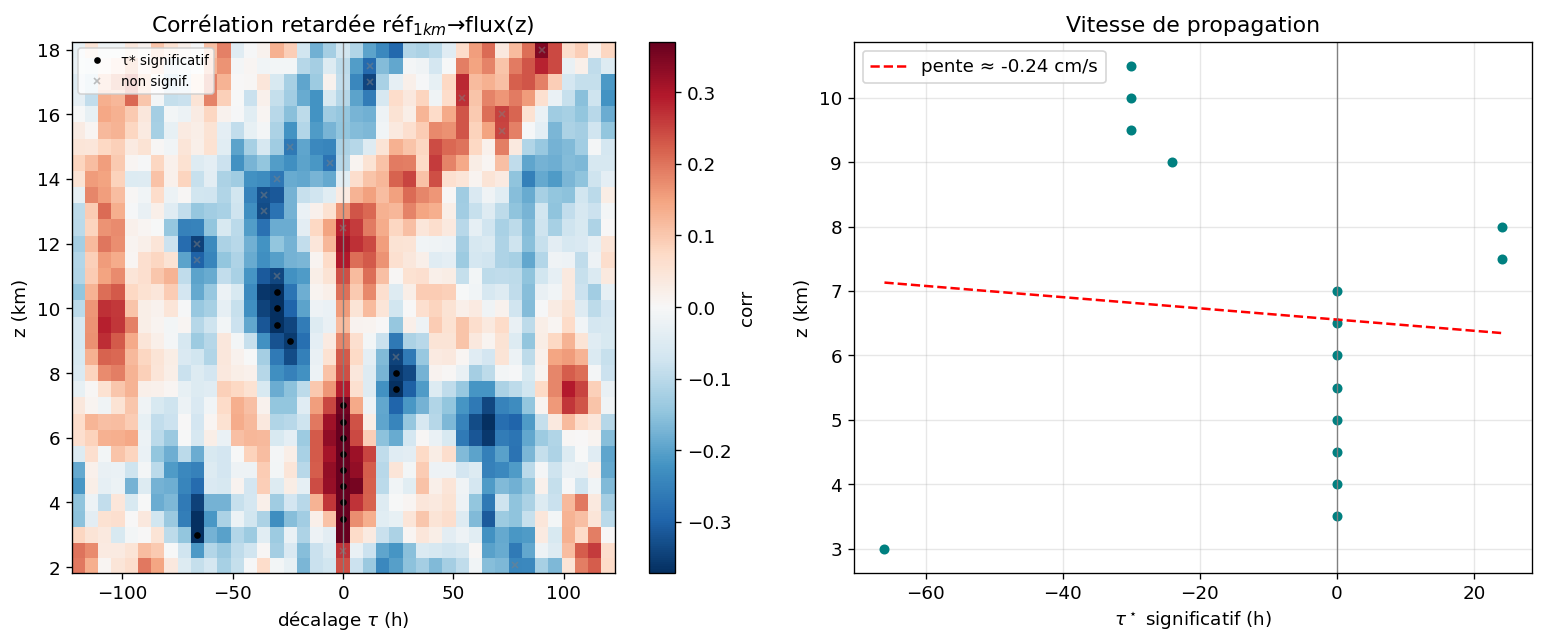

In [21]:
# ============================================================
#  §3.2  Figure : corrélation retardée + tau* SEULEMENT si significatif
# ============================================================
fig,axes=plt.subplots(1,2,figsize=(13,5.5))
lags_h=lags*dt_phys/3600.0

ax=axes[0]; ax.grid(False)
v=np.percentile(np.abs(C),99)
im=ax.pcolormesh(lags_h,zc_km,C,cmap='RdBu_r',norm=TwoSlopeNorm(0,-v,v),shading='auto')
ax.plot(tau_star[signif],zc_km[signif],'k.',ms=6,label='τ* significatif')
ax.plot(tau_star[~signif],zc_km[~signif],'x',color='grey',ms=4,alpha=.5,label='non signif.')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'décalage $\tau$ (h)'); ax.set_ylabel('z (km)')
ax.set_title(r'Corrélation retardée réf$_{1km}\to$flux(z)'); ax.legend(fontsize=8)
fig.colorbar(im,ax=ax,label='corr')

ax=axes[1]
ax.plot(tau_star[signif],zc_km[signif],'o',color='teal',ms=5)
if signif.sum()>=4 and np.ptp(tau_star[signif])>0:
    p=np.polyfit(tau_star[signif],zc_km[signif],1)
    cz=p[0]*1000/3600*100
    tt=np.linspace(tau_star[signif].min(),tau_star[signif].max(),20)
    ax.plot(tt,np.polyval(p,tt),'r--',label=f'pente ≈ {cz:+.2f} cm/s')
    ax.legend()
    txt=f"vitesse de propagation ≈ {cz:+.2f} cm/s"
else:
    txt="trop peu de niveaux significatifs pour une vitesse fiable"
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'$\tau^\star$ significatif (h)'); ax.set_ylabel('z (km)')
ax.set_title('Vitesse de propagation'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


In [27]:
# ============================================================
#  §3.1  Corrélation retardée + seuil de significativité
# ============================================================
from scipy.signal import detrend
iz_ref=np.argmin(np.abs(alt-3000.0))
ref=detrend(flux_zt[iz_ref,:]); ref=(ref-ref.mean())/(ref.std()+1e-30)
Fana=detrend(flux_zt[band,:],axis=1)
Fana=(Fana-Fana.mean(1,keepdims=True))/(Fana.std(1,keepdims=True)+1e-30)
zc_km=zkm[band]

TAU_MAX_H=120.0
Lmax=int(TAU_MAX_H*3600/dt_phys)
lags=np.arange(-Lmax,Lmax+1)
C=np.zeros((band.sum(),lags.size))
for j,L in enumerate(lags):
    if L>=0: a=ref[:n_stat-L]; bb=Fana[:,L:]
    else:    a=ref[-L:];       bb=Fana[:,:n_stat+L]
    C[:,j]=(bb*a).mean(1)

# seuil de significativité ~ 2/sqrt(n_eff), n_eff réduit par l'autocorrélation
n_eff=max(n_stat//3,10)                      # prudent (autocorrélation temporelle)
sig=2/np.sqrt(n_eff)
Cmax=np.max(np.abs(C),axis=1)
tau_star=lags[np.argmax(np.abs(C),axis=1)]*dt_phys/3600.0
signif=Cmax>sig
print(f"seuil de significativité |C|>{sig:.2f}  (n_eff≈{n_eff})")
print(f"niveaux significatifs : {signif.sum()}/{band.sum()}")
print(f"retards significatifs : {tau_star[signif].min():.0f} à {tau_star[signif].max():.0f} h")

seuil de significativité |C|>0.35  (n_eff≈33)
niveaux significatifs : 25/33
retards significatifs : -84 à 120 h


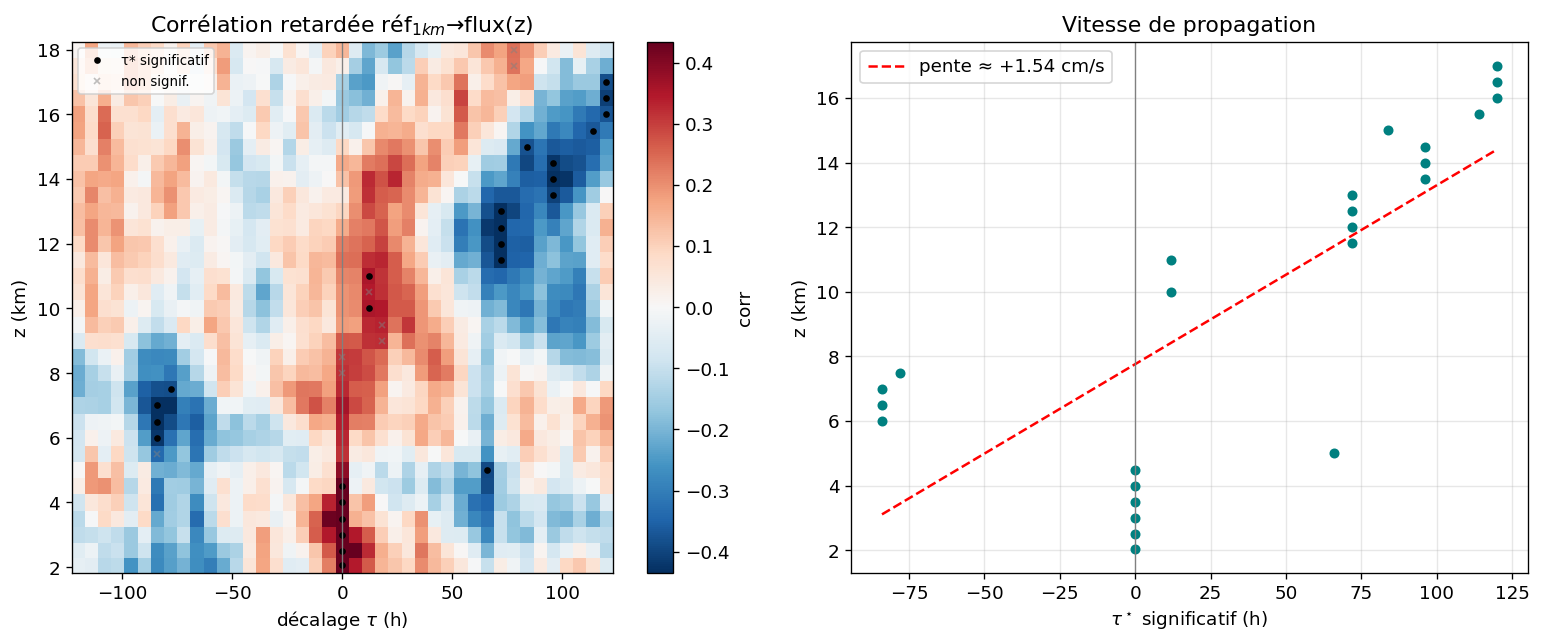

In [28]:
# ============================================================
#  §3.2  Figure : corrélation retardée + tau* SEULEMENT si significatif
# ============================================================
fig,axes=plt.subplots(1,2,figsize=(13,5.5))
lags_h=lags*dt_phys/3600.0

ax=axes[0]; ax.grid(False)
v=np.percentile(np.abs(C),99)
im=ax.pcolormesh(lags_h,zc_km,C,cmap='RdBu_r',norm=TwoSlopeNorm(0,-v,v),shading='auto')
ax.plot(tau_star[signif],zc_km[signif],'k.',ms=6,label='τ* significatif')
ax.plot(tau_star[~signif],zc_km[~signif],'x',color='grey',ms=4,alpha=.5,label='non signif.')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'décalage $\tau$ (h)'); ax.set_ylabel('z (km)')
ax.set_title(r'Corrélation retardée réf$_{1km}\to$flux(z)'); ax.legend(fontsize=8)
fig.colorbar(im,ax=ax,label='corr')

ax=axes[1]
ax.plot(tau_star[signif],zc_km[signif],'o',color='teal',ms=5)
if signif.sum()>=4 and np.ptp(tau_star[signif])>0:
    p=np.polyfit(tau_star[signif],zc_km[signif],1)
    cz=p[0]*1000/3600*100
    tt=np.linspace(tau_star[signif].min(),tau_star[signif].max(),20)
    ax.plot(tt,np.polyval(p,tt),'r--',label=f'pente ≈ {cz:+.2f} cm/s')
    ax.legend()
    txt=f"vitesse de propagation ≈ {cz:+.2f} cm/s"
else:
    txt="trop peu de niveaux significatifs pour une vitesse fiable"
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'$\tau^\star$ significatif (h)'); ax.set_ylabel('z (km)')
ax.set_title('Vitesse de propagation'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

corr min=-0.35  max hors diag=0.98


/tmp/ipykernel_50499/2862927062.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(zc2, zc2, Corr, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')


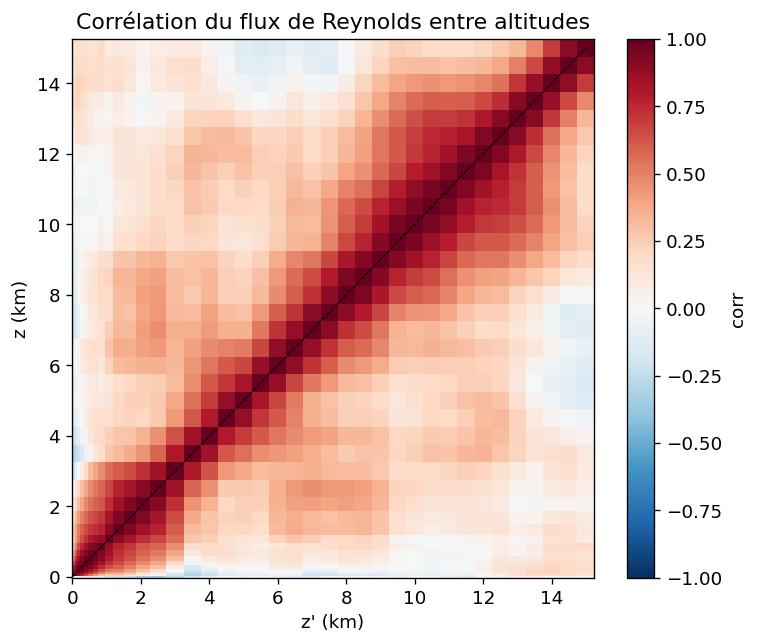

In [16]:
# ============================================================
#  §3.2 (simplifie) — MATRICE DE CORRELATION z / z' du flux de Reynolds
#  Pas de retard temporel : juste corr(flux(z,t), flux(z',t)) sur t
# ============================================================
band2 = (alt >= 0.0) & (alt <= 15000.0)
zc2   = alt[band2] / 1000.0                     # altitudes en km, pour les axes

# --- flux de Reynolds, detrend + centre-reduit, niveau par niveau ------
Fana2 = detrend(flux_zt[band2, :], axis=1)
Fana2 = (Fana2 - Fana2.mean(1, keepdims=True)) / (Fana2.std(1, keepdims=True) + 1e-30)

# --- matrice de correlation : produit matriciel des series standardisees
n_lev = Fana2.shape[0]
Corr = (Fana2 @ Fana2.T) / n_stat               # (n_lev, n_lev), corr de Pearson exacte

print(f"corr min={Corr.min():.2f}  max hors diag={np.abs(Corr - np.eye(n_lev)).max():.2f}")

# ============================================================
#  FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.pcolormesh(zc2, zc2, Corr, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax.plot(zc2, zc2, 'k--', lw=.7)
ax.set_xlabel("z' (km)"); ax.set_ylabel("z (km)")
ax.set_title("Corrélation du flux de Reynolds entre altitudes")
fig.colorbar(im, ax=ax, label='corr')
plt.tight_layout(); plt.show()

corr min=-0.15  max hors diag=0.95


/tmp/ipykernel_50499/594209700.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(zc2, zc2, Corr, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')


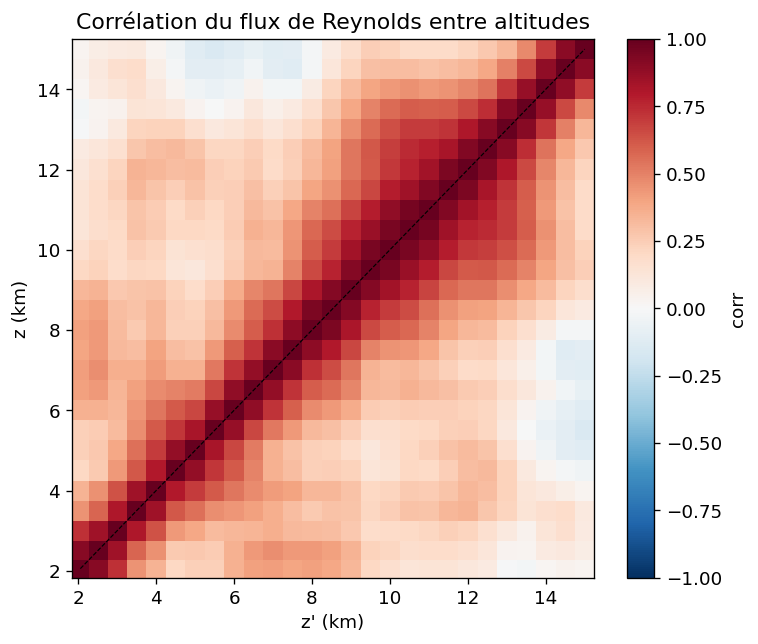

In [18]:
# ============================================================
#  §3.2 (simplifie) — MATRICE DE CORRELATION z / z' du flux de Reynolds
#  Pas de retard temporel : juste corr(flux(z,t), flux(z',t)) sur t
# ============================================================
band2 = (alt >= 2000.0) & (alt <= 15000.0)
zc2   = alt[band2] / 1000.0                     # altitudes en km, pour les axes

# --- flux de Reynolds, detrend + centre-reduit, niveau par niveau ------
Fana2 = detrend(flux_zt[band2, :], axis=1)
Fana2 = (Fana2 - Fana2.mean(1, keepdims=True)) / (Fana2.std(1, keepdims=True) + 1e-30)

# --- matrice de correlation : produit matriciel des series standardisees
n_lev = Fana2.shape[0]
Corr = (Fana2 @ Fana2.T) / n_stat               # (n_lev, n_lev), corr de Pearson exacte

print(f"corr min={Corr.min():.2f}  max hors diag={np.abs(Corr - np.eye(n_lev)).max():.2f}")

# ============================================================
#  FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.pcolormesh(zc2, zc2, Corr, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax.plot(zc2, zc2, 'k--', lw=.7)
ax.set_xlabel("z' (km)"); ax.set_ylabel("z (km)")
ax.set_title("Corrélation du flux de Reynolds entre altitudes")
fig.colorbar(im, ax=ax, label='corr')
plt.tight_layout(); plt.show()